# Two-Triangle Benchmark Report

This notebook reads the latest run under `benchmarks/two_triangle/results/runs/`
and produces six standard comparison outputs:

1. Per-case winner table
2. Variants × cases speed heatmap (vs baseline)
3. Variants × cases accuracy heatmap (vs baseline)
4. Pareto scatter: speed vs final folds
5. Trajectory overlays for real cases (fold count vs time)
6. Solution-quality table (l2_disp, smoothness vs baseline)

To refresh: re-run all cells.

In [1]:
import json
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure repo root is on sys.path so benchmarks package is importable.
# nbconvert runs with cwd = directory of the notebook (benchmarks/two_triangle/).
_NOTEBOOK_DIR = Path(".").resolve()
_REPO_ROOT = _NOTEBOOK_DIR.parents[1]  # two_triangle -> benchmarks -> repo root
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

from benchmarks.two_triangle.result import SolverResult  # noqa: E402

RUNS_DIR = _NOTEBOOK_DIR / "results" / "runs"
latest = sorted(RUNS_DIR.iterdir())[-1]
manifest = json.loads((latest / "manifest.json").read_text())
print(f"Run: {latest.name}  |  cells: {manifest['n_cells']}  |  git: {manifest['git_sha'][:8]}")
cells = pd.DataFrame(manifest["cells"])
ok = cells[cells["status"] == "ok"].copy()
print(f"  ok: {len(ok)}  |  errors: {(cells['status'] == 'error').sum()}  |  skipped: {(cells['status'] == 'skipped').sum()}")
ok.head()

Run: 20260509T011154Z  |  cells: 4  |  git: e5d41b88
  ok: 4  |  errors: 0  |  skipped: 0


,variant,case,case_meta,started_at,status,wall_s,rss_before_mb,rss_after_mb,rss_delta_mb,converged,timed_out,final_folds_jdet,final_folds_tri,n_traj_rows,parquet
0,baseline_serial,synth2d_single_cell_flip,"{'category': 'synthetic_2d', 'dim': 2}",20260509T011154Z,ok,0.010907,144.863281,146.687500,1.824219,True,False,0,0,1,baseline_serial\synth2d_single_cell_flip.parquet
1,baseline_serial,synth2d_horizontal_bowtie,"{'category': 'synthetic_2d', 'dim': 2}",20260509T011154Z,ok,0.165409,150.023438,154.066406,4.042969,True,False,0,0,1,baseline_serial\synth2d_horizontal_bowtie.parquet
2,combinatorial_prefix,synth2d_single_cell_flip,"{'category': 'synthetic_2d', 'dim': 2}",20260509T011154Z,ok,0.009627,150.394531,150.886719,0.492188,True,False,0,0,3,combinatorial_prefix\synth2d_single_cell_flip....
3,combinatorial_prefix,synth2d_horizontal_bowtie,"{'category': 'synthetic_2d', 'dim': 2}",20260509T011154Z,ok,0.162615,150.894531,152.871094,1.976562,True,False,0,0,3,combinatorial_prefix\synth2d_horizontal_bowtie...


In [2]:
# 1. Per-case winner: minimize fold_count_tri × wall_s
ok["score"] = (ok["final_folds_tri"] + 1) * ok["wall_s"]
winners = (ok.sort_values("score")
             .groupby("case", as_index=False)
             .first()[["case", "variant", "final_folds_tri", "wall_s", "score"]])
winners

,case,variant,final_folds_tri,wall_s,score
0,synth2d_horizontal_bowtie,combinatorial_prefix,0,0.162615,0.162615
1,synth2d_single_cell_flip,combinatorial_prefix,0,0.009627,0.009627


C:\Users\Andy\AppData\Local\Temp\ipykernel_50864\2326111264.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


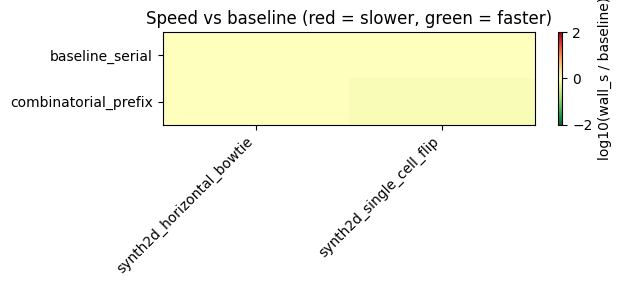

In [3]:
# 2. Speed heatmap: log10(wall_s / baseline_wall_s)
pivot_time = ok.pivot(index="variant", columns="case", values="wall_s")
baseline = pivot_time.loc["baseline_serial"]
log_ratio = np.log10(pivot_time / baseline)
fig, ax = plt.subplots(figsize=(max(6, 1.2 * len(pivot_time.columns)), 0.6 * len(pivot_time)))
im = ax.imshow(log_ratio, cmap="RdYlGn_r", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(pivot_time.columns))); ax.set_xticklabels(pivot_time.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_time.index))); ax.set_yticklabels(pivot_time.index)
plt.colorbar(im, ax=ax, label="log10(wall_s / baseline)")
ax.set_title("Speed vs baseline (red = slower, green = faster)")
plt.tight_layout(); plt.show()

C:\Users\Andy\AppData\Local\Temp\ipykernel_50864\2632934087.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


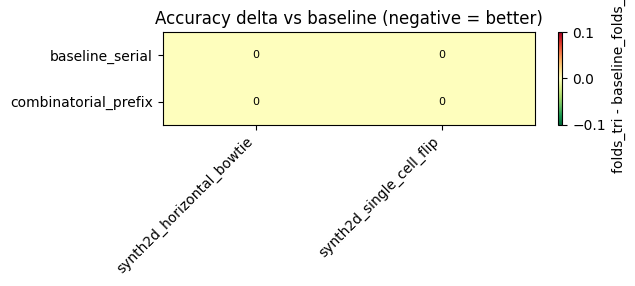

In [4]:
# 3. Accuracy heatmap: final_folds_tri minus baseline
pivot_folds = ok.pivot(index="variant", columns="case", values="final_folds_tri")
delta = pivot_folds.sub(pivot_folds.loc["baseline_serial"], axis="columns")
fig, ax = plt.subplots(figsize=(max(6, 1.2 * len(pivot_folds.columns)), 0.6 * len(pivot_folds)))
im = ax.imshow(delta, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(len(pivot_folds.columns))); ax.set_xticklabels(pivot_folds.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_folds.index))); ax.set_yticklabels(pivot_folds.index)
for i in range(delta.shape[0]):
    for j in range(delta.shape[1]):
        ax.text(j, i, int(delta.iloc[i, j]), ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, label="folds_tri - baseline_folds_tri")
ax.set_title("Accuracy delta vs baseline (negative = better)")
plt.tight_layout(); plt.show()

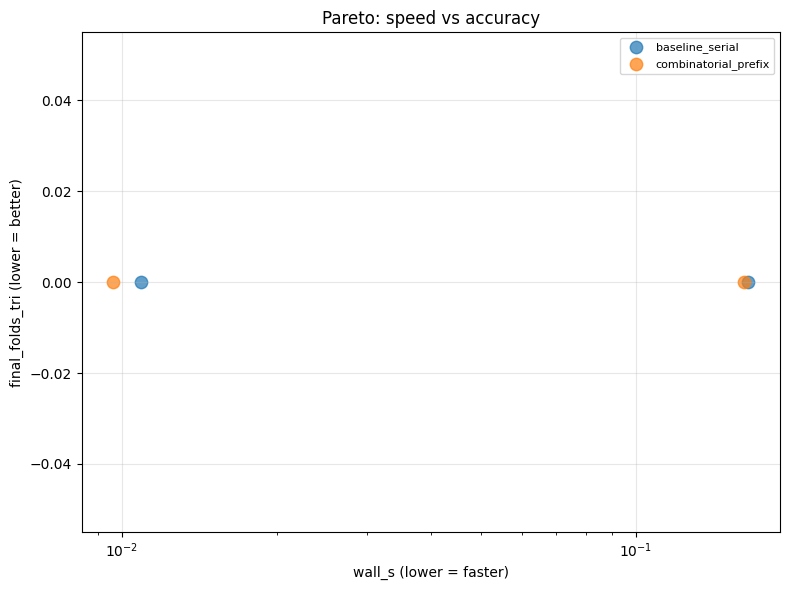

In [5]:
# 4. Pareto scatter: speed vs folds
fig, ax = plt.subplots(figsize=(8, 6))
for v, group in ok.groupby("variant"):
    ax.scatter(group["wall_s"], group["final_folds_tri"], label=v, s=80, alpha=0.7)
ax.set_xlabel("wall_s (lower = faster)"); ax.set_ylabel("final_folds_tri (lower = better)")
ax.set_xscale("log")
ax.legend(loc="best", fontsize=8); ax.grid(alpha=0.3)
ax.set_title("Pareto: speed vs accuracy")
plt.tight_layout(); plt.show()

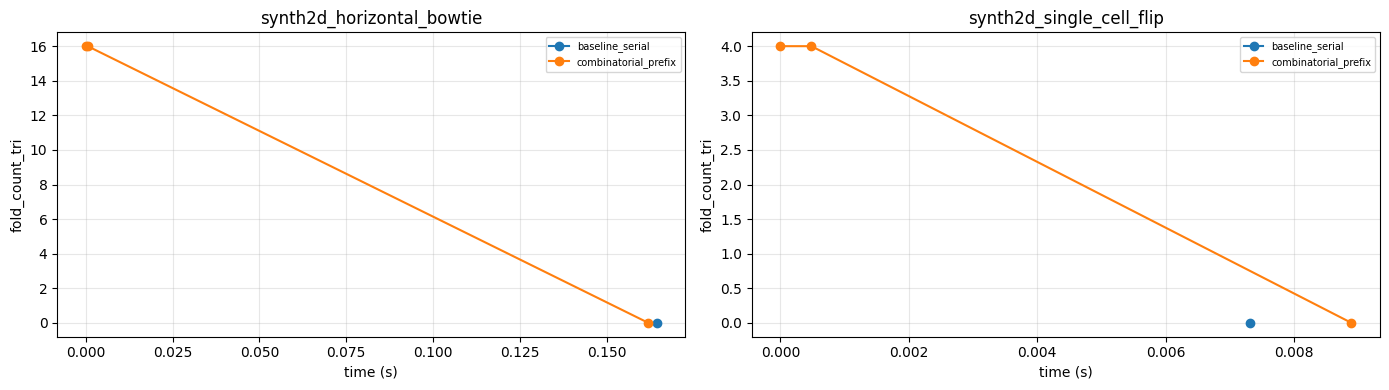

In [6]:
# 5. Trajectory overlays for the 2 longest-running cases (proxy for "real" or hard)
hardest = ok.groupby("case")["wall_s"].max().nlargest(2).index.tolist()
fig, axes = plt.subplots(1, len(hardest), figsize=(7 * len(hardest), 4), squeeze=False)
for ax, case in zip(axes[0], hardest):
    for _, row in ok[ok["case"] == case].iterrows():
        parquet = latest / row["parquet"]
        if not parquet.exists():
            continue
        traj = pd.read_parquet(parquet)
        ax.plot(traj["time_s"], traj["fold_count_tri"], marker="o", label=row["variant"])
    ax.set_title(case); ax.set_xlabel("time (s)"); ax.set_ylabel("fold_count_tri")
    ax.grid(alpha=0.3); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

In [7]:
# 6. Solution quality: l2_disp + smoothness deltas
def _final_metric(parquet, col):
    return float(pd.read_parquet(latest / parquet).iloc[-1][col])

ok["final_l2_disp"] = ok["parquet"].apply(lambda p: _final_metric(p, "l2_disp"))
ok["final_smoothness"] = ok["parquet"].apply(lambda p: _final_metric(p, "smoothness"))
quality = ok[["case", "variant", "final_l2_disp", "final_smoothness"]].pivot(
    index="variant", columns="case")
quality

final_l2_disp                           \
case                 synth2d_horizontal_bowtie synth2d_single_cell_flip   
variant                                                                   
baseline_serial                       2.995268                 1.442403   
combinatorial_prefix                  2.995268                 1.442403   

                              final_smoothness                           
case                 synth2d_horizontal_bowtie synth2d_single_cell_flip  
variant                                                                  
baseline_serial                       3.087346                 1.966713  
combinatorial_prefix                  3.087346                 1.966713